This routine generates **Figure 1 municipal and global withdrawal reduction and displacement**. If you have any questions please contact [a.sarfraz@uu.nl](mailto:a.sarfraz@uu.nl).


### Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

### Setting directories

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import yaml

# Resolve the repo root from this notebook's location.
_NB_DIR   = Path.cwd()
REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == "notebooks" else _NB_DIR

sys.path.insert(0, str(REPO_ROOT / "src"))

# Load path config.
_cfg = yaml.safe_load((REPO_ROOT / "config" / "paths.yaml").read_text())

def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p).resolve()

PATHS = {
    "data":    {k: _resolve(v) for k, v in _cfg["data"].items()},
    "outputs": {k: _resolve(v) for k, v in _cfg["outputs"].items()},
}

from potable_reuse.style import apply_style
from potable_reuse.io import load_scenario_query
from potable_reuse.plotting import save_all
apply_style()

CACHE_DIR = PATHS["data"]["cache_dir"]
FIG_DIR   = PATHS["outputs"]["figure1"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

### Loading cached data



In [3]:
muni  = pd.read_parquet(CACHE_DIR / "combined_muni.parquet")
total = pd.read_parquet(CACHE_DIR / "combined_total.parquet")

# Ensemble is PR0 (no reuse) and PR100 (full adoption) only.
muni  = muni[muni["pr"].isin(["PR0", "PR100"])].copy()
total = total[total["pr"].isin(["PR0", "PR100"])].copy()

print(f"muni  : {len(muni):,} rows | "
      f"{muni['scenario'].nunique()} scenarios")
print(f"total : {len(total):,} rows | "
      f"{total['scenario'].nunique()} scenarios")

muni  : 215,424 rows | 306 scenarios
total : 3,383,136 rows | 306 scenarios


### Constants and helpers


In [4]:
START_YEAR = 2025
END_YEAR   = 2100
DECADES    = [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]

PR_LEVELS = ["PR100"]
PR_COLOR  = {"PR100": "#2E7D32"}

# Sector classification from'water mapping source'
SECTOR_MAP = {
    "water_td_muni_W":   "Municipal",
    "water_td_irr_W":    "Irrigation",
    "water_td_elec_W":   "Electricity",
    "water_td_ind_W":    "Manufacturing",
    "water_td_an_W":     "Livestock",
    "water_td_pri_W":    "Primary energy",
}
SECTOR_ORDER = [
    "Municipal", "Irrigation", "Electricity",
    "Manufacturing", "Livestock", "Primary energy",
]


FATE_ORDER = [
    "Net withdrawal reduction",
    "Reallocated to irrigation",
    "Reallocated to electricity",
    "Reallocated to manufacturing",
    "Reallocated to livestock",
    "Reallocated to primary energy",
]
FATE_COLOR = {
    "Net withdrawal reduction":      "#44BB99",  # mint
    "Reallocated to irrigation":     "#EE8866",  # light orange
    "Reallocated to electricity":    "#77AADD",  # light blue
    "Reallocated to manufacturing":  "#EEDD88",  # pale yellow
    "Reallocated to livestock":      "#BBCC33",  # pear
    "Reallocated to primary energy": "#FFAABB",  # light pink
}
FATE_COL = {f: f.lower().replace(" ", "_") for f in FATE_ORDER}


def hex_to_rgba_mpl(hex_color, alpha):
    """Convert a hex color to an RGBA tuple matplotlib accepts."""
    h = hex_color.lstrip("#")
    r = int(h[0:2], 16) / 255
    g = int(h[2:4], 16) / 255
    b = int(h[4:6], 16) / 255
    return (r, g, b, alpha)


def hex_to_rgba(hex_color, alpha):
    """Convert a hex color to a Plotly rgba(...) string."""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

PR_LABEL = {
    "PR0":   "No reuse",
    "PR100": "Full adoption",
}
BASELINE_PR    = "PR0"
BASELINE_PHRASE = "no-reuse baseline"


def pr_label(pr, n=None):
    """Plain-language adoption label, with ensemble size when supplied."""
    lab = PR_LABEL.get(pr, pr)
    return lab if n is None else f"{lab} (n = {n:,})"


def ensemble_size(df, pr, value_col="pct_reduction", years=None):
    """Number of ensemble members behind one adoption level.

    Returns the per-year count when it is constant across years, which is the
    expected case for a fully crossed design, and the maximum otherwise.
    """
    sub = df[df["pr"] == pr]
    if years is not None:
        sub = sub[sub["year"].isin(years)]
    counts = sub.dropna(subset=[value_col]).groupby("year")[value_col].size()
    if counts.empty:
        return 0
    return int(counts.iloc[0]) if counts.nunique() == 1 else int(counts.max())


SECTOR_COLOR = {
    "Municipal":      "#334F7D",
    "Irrigation":     "#EE8866",
    "Electricity":    "#77AADD",
    "Manufacturing":  "#EEDD88",
    "Livestock":      "#BBCC33",
    "Primary energy": "#FFAABB",
}
NET_COLOR = "#000000"                     # net-change indicator on panel (c)
NET_FILL  = FATE_COLOR["Net withdrawal reduction"]   # net wedge on panel (d)
MEMBER_KEYS = ["ssp_rcp", "rc", "supply"]



MAIN_YEARS = DECADES
PR_MAIN    = "PR100"


RC_ORDER = ["LRC", "MRC", "HRC"]      # drawn bottom to top within each violin
RC_COLOR = {"LRC": "#009988",         # teal-green
            "MRC": "#FFC857",         # mustard
            "HRC": "#CC3311"}         # red
RC_LABEL = {"LRC": "Low reuse cost",
            "MRC": "Medium reuse cost",
            "HRC": "High reuse cost"}
VIOLIN_ALPHA = 0.85


### Aggregating to global totals


In [5]:
def sum_to_global(df, value_col="value"):
    """Collapse a scenario-region-year frame to global totals."""
    df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)]
    keys = ["scenario", "ssp_rcp", "ssp", "rcp",
            "rc", "supply", "pr", "year"]
    keys = [k for k in keys if k in df.columns]
    return (df.groupby(keys)[value_col]
              .sum()
              .reset_index()
              .rename(columns={value_col: "withdrawal"}))


def compute_pct_reduction(df, id_cols):
    """Pair each PR scenario with its matched PR0 baseline
    and compute the percentage reduction on `withdrawal`."""
    ref = (df[df["pr"] == "PR0"][id_cols + ["withdrawal"]]
             .rename(columns={"withdrawal": "ref"}))
    out = df[df["pr"] != "PR0"].merge(ref, on=id_cols, how="left")
    out["pct_reduction"] = (out["ref"] - out["withdrawal"]) / out["ref"] * 100
    return out


# Global totals: total freshwater (top-level sum of `total`)
# and municipal-only.
total_glob = sum_to_global(total)
muni_glob  = sum_to_global(muni)

# Reductions vs the matched PR0 baseline.
id_cols = ["ssp_rcp", "rc", "supply", "year"]
total_red = compute_pct_reduction(total_glob, id_cols)
muni_red  = compute_pct_reduction(muni_glob,  id_cols)

print(f"total_red : {len(total_red):,} rows")
print(f"muni_red  : {len(muni_red):,} rows")

total_red : 2,448 rows
muni_red  : 2,448 rows


### Sectoral change against the no-reuse baseline

Builds `global_delta` (change in withdrawal per sector, scenario and year
against the matched PR0 run), and from it `fate` and `gross`, which the
headline numbers and panel (c) of Figure 1 use.

In [6]:
def classify_input(inp):
    """Map a GCAM `input` field to one of our six sectors.
    """
    if not isinstance(inp, str):
        return "Other"
    s = inp.lower()
    if s.startswith("water_td_irr"): return "Irrigation"
    if s == "water_td_muni_w":       return "Municipal"
    if s == "water_td_an_w":         return "Livestock"
    if s == "water_td_elec_w":       return "Electricity"
    if s == "water_td_ind_w":        return "Manufacturing"
    if s == "water_td_pri_w":        return "Primary energy"
    return "Other"


def build_sectoral_long(total, muni):
    """Stack non-municipal sectors (from `total`) onto the
    municipal cache (`muni`).

    """
    t = total.copy()
    t["sector"] = t["input"].map(classify_input)
    t = t[~t["sector"].isin(["Municipal", "Other"])]

    m = muni.copy()
    m["sector"] = "Municipal"

    # Derive ssp / rcp from ssp_rcp on either frame if not already present.
    for f in (t, m):
        if "ssp" not in f.columns and "ssp_rcp" in f.columns:
            f["ssp"] = f["ssp_rcp"].str.split("_").str[0]
        if "rcp" not in f.columns and "ssp_rcp" in f.columns:
            f["rcp"] = f["ssp_rcp"].str.split("_").str[1]

    keep = ["scenario", "ssp_rcp", "ssp", "rcp",
            "rc", "supply", "pr", "region", "year", "sector", "value"]
    keep_t = [c for c in keep if c in t.columns]
    keep_m = [c for c in keep if c in m.columns]
    return pd.concat([t[keep_t], m[keep_m]], ignore_index=True)


def aggregate_global_by_sector(df):
    """Sum withdrawals to (sector, year, scenario design) global totals."""
    df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)]
    df = df[df["sector"].isin(SECTOR_ORDER)]
    keys = ["ssp_rcp", "ssp", "rcp", "rc", "supply",
            "pr", "sector", "year"]
    return df.groupby(keys, as_index=False)["value"].sum()


def compute_sectoral_delta(global_by_sector):
    """Per-sector delta against the matched PR0 baseline."""
    id_cols = ["ssp_rcp", "ssp", "rcp", "rc", "supply",
               "sector", "year"]
    ref = (global_by_sector[global_by_sector["pr"] == "PR0"]
             [id_cols + ["value"]]
             .rename(columns={"value": "ref"}))
    out = global_by_sector[global_by_sector["pr"] != "PR0"].merge(
        ref, on=id_cols, how="left")
    out["delta"] = out["value"] - out["ref"]
    return out


def fate_table(global_delta):
    """Decompose ensemble-median deltas into the six fate channels.

    For a given (pr, year):
        gross_municipal     = -median(delta for Municipal)        (>= 0)
        reallocation[s]     = max(0, median(delta for sector s))  for s != Municipal
        net_reduction       = max(0, gross_municipal - sum reallocations)
    """
    med = (global_delta
           .groupby(["pr", "sector", "year"], as_index=False)["delta"]
           .median())
    rows = []
    for (pr, year), sub in med.groupby(["pr", "year"]):
        s = dict(zip(sub["sector"], sub["delta"]))
        muni = -s.get("Municipal", 0.0)
        if muni <= 0:
            continue
        row = {"pr": pr, "year": year, "gross_municipal": muni}
        net = muni
        for sector in ["Irrigation", "Electricity",
                       "Manufacturing", "Livestock",
                       "Primary energy"]:
            realloc = max(0.0, s.get(sector, 0.0))
            row[FATE_COL[f"Reallocated to {sector.lower()}"]] = realloc
            net -= realloc
        row[FATE_COL["Net withdrawal reduction"]] = max(0.0, net)
        rows.append(row)
    return pd.DataFrame(rows)


def gross_percentiles(global_delta):
    """Whiskers for the gross-reduction marker on panel (c)."""
    muni = (global_delta[global_delta["sector"] == "Municipal"]
            .copy())
    muni["gross"] = -muni["delta"]
    return (muni.groupby(["pr", "year"], as_index=False)
                .agg(median=("gross", "median"),
                     q25=("gross", lambda s: s.quantile(0.25)),
                     q75=("gross", lambda s: s.quantile(0.75)),
                     q05=("gross", lambda s: s.quantile(0.05)),
                     q95=("gross", lambda s: s.quantile(0.95))))


sectoral_long    = build_sectoral_long(total, muni)
global_by_sector = aggregate_global_by_sector(sectoral_long)
global_delta     = compute_sectoral_delta(global_by_sector)
fate             = fate_table(global_delta)
gross            = gross_percentiles(global_delta)

# re-check
print("Sectors present in global_delta:")
print(global_delta
      .groupby("sector")["delta"]
      .apply(lambda s: f"n={len(s):,d}, median delta={s.median():+.2f}")
      .to_string())

print(f"\nfate    : {len(fate):,} rows ({fate['pr'].unique()})")
print(f"gross   : {len(gross):,} rows")

def sector_delta_medians(global_delta, pr, years=DECADES):
    """Ensemble-median signed change in withdrawal by sector."""
    med = (global_delta[global_delta["pr"] == pr]
           .groupby(["sector", "year"], as_index=False)["delta"]
           .median())
    wide = med.pivot(index="year", columns="sector", values="delta")
    for sec in SECTOR_ORDER:
        if sec not in wide.columns:
            wide[sec] = 0.0
    return wide[SECTOR_ORDER].reindex(years).fillna(0.0)


def net_change_percentiles(global_delta, pr, years=DECADES):
    """Member-wise net change in total withdrawal, summed over all sectors.

    Percentiles are taken across ensemble members, so the median reported here
    is a median of sums and can differ slightly from the sum of the sectoral
    medians drawn as bars.
    """
    keys = [k for k in MEMBER_KEYS if k in global_delta.columns]
    net = (global_delta[global_delta["pr"] == pr]
           .groupby(keys + ["year"], as_index=False)["delta"]
           .sum()
           .rename(columns={"delta": "net"}))
    return (net.groupby("year")["net"]
               .agg(median="median",
                    q25=lambda s: s.quantile(0.25),
                    q75=lambda s: s.quantile(0.75),
                    q05=lambda s: s.quantile(0.05),
                    q95=lambda s: s.quantile(0.95),
                    n="size")
               .reindex(years))


def fate_shares(global_delta, pr, years=DECADES):
    """Fate of the gross municipal reduction as percentages summing to 100."""
    M      = sector_delta_medians(global_delta, pr, years)
    gross  = -M["Municipal"]
    others = [s for s in SECTOR_ORDER if s != "Municipal"]
    out    = pd.DataFrame(index=M.index)
    for sec in others:
        out[sec] = M[sec] / gross.replace(0, np.nan) * 100
    out["Net withdrawal reduction"] = 100 - out[others].sum(axis=1)
    return out.fillna(0.0)


# Consistency check between the clipped and the unclipped partitions.
for _pr in PR_LEVELS:
    _M     = sector_delta_medians(global_delta, _pr)
    _net   = _M.sum(axis=1)
    _gross = -_M["Municipal"]
    _clip  = (fate[fate["pr"] == _pr]
              .set_index("year")["net_withdrawal_reduction"]
              .reindex(DECADES))
    print(f"{pr_label(_pr)}: gross {_gross.loc[2100]:7.2f}, "
          f"net {-_net.loc[2100]:7.2f} km3/yr at 2100 | "
          f"max |unclipped - clipped| net = "
          f"{(-_net - _clip).abs().max():.3f} km3/yr")


Sectors present in global_delta:
sector
Electricity         n=2,448, median delta=+3.75
Irrigation         n=2,448, median delta=+12.27
Livestock           n=2,448, median delta=+0.03
Manufacturing       n=2,448, median delta=+0.12
Municipal         n=2,448, median delta=-149.21
Primary energy      n=2,448, median delta=-0.01

fate    : 16 rows (['PR100'])
gross   : 16 rows
Full adoption: gross  189.38, net  140.15 km3/yr at 2100 | max |unclipped - clipped| net = 0.021 km3/yr


### Headline numbers

Writes a small text file with the median values cited in the manuscript (gross municipal reduction, sector-by-sector reallocation shares, net retention) for PR100. Useful as a quick check that the figure outputs and the body text.

In [7]:
def headline_numbers(fate_df, gross_df,
                     years=(2030, 2050, 2075, 2100),
                     pr_levels=None):
    """
    Print ensemble-median headline numbers for each (PR, year) pair, with
    IQR (q25-q75) and 5-95% ranges for the gross municipal reduction.
    """
    if pr_levels is None:
        pr_levels = PR_LEVELS

    lines = []
    for pr in pr_levels:
        lines.append(f"\n{'=' * 72}")
        lines.append(f"  {pr}")
        lines.append(f"{'=' * 72}")

        for year in years:
            row = fate_df[(fate_df["pr"] == pr) & (fate_df["year"] == year)]
            if row.empty:
                lines.append(f"\n  --- {year}: no data ---")
                continue
            row = row.iloc[0]
            muni = row["gross_municipal"]

            g = gross_df[(gross_df["pr"] == pr) & (gross_df["year"] == year)]
            g_iqr = g.iloc[0] if not g.empty else None

            lines.append(f"\n  --- {year} (ensemble medians) ---")
            if g_iqr is not None:
                lines.append(
                    f"    Gross municipal reduction      = {muni:6.1f} km3 yr-1  "
                    f"(IQR {g_iqr['q25']:.1f}-{g_iqr['q75']:.1f}; "
                    f"5-95% {g_iqr['q05']:.1f}-{g_iqr['q95']:.1f})"
                )
            else:
                lines.append(
                    f"    Gross municipal reduction      = {muni:6.1f} km3 yr-1"
                )

            for sector in ["irrigation", "electricity", "manufacturing",
                           "livestock", "primary energy"]:
                v = row[FATE_COL[f"Reallocated to {sector}"]]
                pct = 100 * v / muni if muni else 0
                lines.append(
                    f"    Reallocated to {sector:<14s} = {v:6.1f}  "
                    f"({pct:4.1f}% of gross)"
                )

            net = row[FATE_COL["Net withdrawal reduction"]]
            net_pct = 100 * net / muni if muni else 0
            lines.append(
                f"    Net withdrawal reduction       = {net:6.1f}  "
                f"({net_pct:4.1f}%)"
            )
    return "\n".join(lines)


# Match the years + PR levels shown in Figure 1
YEARS_REPORT = [2030, 2050, 2075, 2100]
PR_REPORT    = ["PR100"]

text = headline_numbers(fate, gross, years=YEARS_REPORT, pr_levels=PR_REPORT)
out  = FIG_DIR / "headline_numbers.txt"
out.write_text(text, encoding="utf-8")
print(text)
print(f"\nWrote {out}")


  PR100

  --- 2030 (ensemble medians) ---
    Gross municipal reduction      =   67.6 km3 yr-1  (IQR 4.5-153.9; 5-95% 3.6-164.7)
    Reallocated to irrigation     =    3.9  ( 5.8% of gross)
    Reallocated to electricity    =    0.2  ( 0.4% of gross)
    Reallocated to manufacturing  =    0.0  ( 0.1% of gross)
    Reallocated to livestock      =    0.0  ( 0.0% of gross)
    Reallocated to primary energy =    0.0  ( 0.0% of gross)
    Net withdrawal reduction       =   63.4  (93.8%)

  --- 2050 (ensemble medians) ---
    Gross municipal reduction      =  136.9 km3 yr-1  (IQR 11.4-262.9; 5-95% 8.1-274.2)
    Reallocated to irrigation     =   13.5  ( 9.9% of gross)
    Reallocated to electricity    =    4.5  ( 3.3% of gross)
    Reallocated to manufacturing  =    0.1  ( 0.1% of gross)
    Reallocated to livestock      =    0.0  ( 0.0% of gross)
    Reallocated to primary energy =    0.0  ( 0.0% of gross)
    Net withdrawal reduction       =  118.8  (86.8%)

  --- 2075 (ensemble medians)

In [8]:
d = muni_red[(muni_red["pr"] == "PR100") & (muni_red["year"] == 2100)].copy()
d["saving_km3"] = d["ref"] - d["withdrawal"]

med_pct = d["pct_reduction"].median()
near    = d.iloc[(d["pct_reduction"] - med_pct).abs().argsort()[:3]]

print(f"Median % reduction           : {med_pct:.1f} %")
print(f"Median absolute saving       : {d['saving_km3'].median():.0f} km3/yr")
print(f"Saving of members at median %: {near['saving_km3'].round(0).tolist()} km3/yr")
print(f"Median % x median baseline   : {med_pct/100 * d['ref'].median():.0f} km3/yr")
print(f"Median baseline (PR0)        : {d['ref'].median():.0f} km3/yr")

Median % reduction           : 29.3 %
Median absolute saving       : 189 km3/yr
Saving of members at median %: [179.0, 179.0, 179.0] km3/yr
Median % x median baseline   : 181 km3/yr
Median baseline (PR0)        : 619 km3/yr


## Figure 1 plotting

In [9]:
# =============================================================================
# Figure 1 plotting (PR100 against the PR0 baseline).
#   draw_swarm_panel  beeswarm of the ensemble with the median as a white spot
#   draw_net_panel    sectoral decomposition of the reduction in total withdrawal
#   make_figure1      the three panel figure for PR100
# =============================================================================

import io
from pathlib import Path

from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

MM    = 1 / 25.4
FIG_W = 180 * MM            # Nature Water double-column measure
FIG_H = 170 * MM

SWARM_YEARS = [2030, 2050, 2075, 2100]
NET_YEARS   = DECADES

PANEL_TITLE = {"a": "", "b": "", "c": ""}
TITLE_SIZE  = 6.0
LEGEND_SIZE = 8

SWARM_COLOR = {                       # (dots, unused, median edge)
    "PR100": ("#7FB77E", "#2E7D32", "#14532D"),
}

RC_FIG = {
    "font.size": 6, "axes.labelsize": 7, "axes.linewidth": 0.6,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 5.5,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5, "savefig.dpi": 600,
    "svg.fonttype": "none",           # keep text editable in the SVG
}


def _panel_letter(ax, letter, dx=-0.105, dy=1.04):
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=8,
            fontweight="bold", va="bottom", ha="left")


def _beeswarm_offsets(y, y_span, half_width, marker_frac=0.026):
    """Symmetric, non-overlapping x offsets for a column of points."""
    y = np.asarray(y, float)
    if y.size == 0:
        return np.zeros(0)
    bin_h  = max(y_span * marker_frac, 1e-9)
    idx    = np.floor((y - y.min()) / bin_h).astype(int)
    widest = max(np.bincount(idx).max(), 1)
    dx     = min(marker_frac * 2.6, (2 * half_width) / max(widest - 1, 1))
    off    = np.zeros(y.size)
    for b in np.unique(idx):
        sel   = np.flatnonzero(idx == b)
        steps = np.array([((i + 1) // 2) * (1 if i % 2 == 0 else -1)
                          for i in range(sel.size)], float)
        off[sel] = steps * dx
    return off


def draw_swarm_panel(ax, df, ylabel, prs, years=None, title=None,
                     half_width=0.30, offset=0.22, ms=10.0, alpha=0.80,
                     colors=None, legend=False):
    """Beeswarm of the ensemble with the median as a white spot.

    With more than one PR the swarms of a year sit side by side, offset
    from the tick; half_width must stay below offset so they do not overlap.
    """
    years  = SWARM_YEARS if years is None else years
    colors = SWARM_COLOR if colors is None else colors
    marker_frac = 0.026 * np.sqrt(ms / 2.0)

    pooled = np.concatenate([df[(df["pr"] == p) & (df["year"] == y)]
                               ["pct_reduction"].dropna().to_numpy()
                             for p in prs for y in years])
    span = float(pooled.max() - pooled.min()) or 1.0
    n = len(prs)

    for pi, pr in enumerate(prs):
        dot, _, med_edge = colors[pr]
        for xi, y in enumerate(years):
            v = df[(df["pr"] == pr) & (df["year"] == y)][
                "pct_reduction"].dropna().to_numpy()
            if v.size == 0:
                continue
            x0 = xi + (pi - (n - 1) / 2) * 2 * offset
            ax.scatter(x0 + _beeswarm_offsets(v, span, half_width, marker_frac),
                       v, s=ms, color=dot, alpha=alpha, linewidths=0, zorder=3)
            ax.plot([x0], [np.median(v)], marker="o", markersize=4.2,
                    markerfacecolor="white", markeredgecolor=med_edge,
                    markeredgewidth=0.9, zorder=7)

    ax.set_xticks(np.arange(len(years)))
    ax.set_xticklabels([str(y) for y in years])
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Year")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.set_ylim(0, float(pooled.max()) * 1.06)
    ax.set_xlim(-0.62, len(years) - 0.38)
    ax.spines[["top", "right"]].set_visible(False)
    if title:
        ax.set_title(title, fontsize=TITLE_SIZE, loc="left", pad=4)

    if not legend:
        return []
    handles = []
    for pr in prs:
        dot, _, med_edge = colors[pr]
        member_label = "Ensemble member" if n == 1 else f"Ensemble member ({pr})"
        handles += [
            Line2D([0], [0], marker="o", color="none",
                   markersize=LEGEND_SIZE * 0.55, markerfacecolor=dot,
                   label=member_label),
            Line2D([0], [0], linestyle="none", marker="o",
                   markersize=LEGEND_SIZE * 0.70, markerfacecolor="white",
                   markeredgecolor=med_edge, markeredgewidth=1.2,
                   label="Ensemble median"),
        ]
    return handles


# ---- Panel (c) --------------------------------------------------------------

SECTOR_ORDER = ["Municipal", "Irrigation", "Livestock",
                "Electricity", "Manufacturing", "Primary energy"]
SECTOR_COLOR = {
    "Municipal":      "#99DDFF",
    "Irrigation":     "#44BB99",
    "Livestock":      "#EEDD88",
    "Electricity":    "#EE8866",
    "Manufacturing":  "#FFAABB",
    "Primary energy": "#DDDDDD",
}
NET_MARKER   = "^"                   
NET_COLOR    = "#222222"


def member_pct_change(global_delta, total_glob, pr, years):
    """Per-member sectoral change as % of that member's matched PR0 total.

    The denominator is the PR0 total freshwater withdrawal of the same
    ssp_rcp / rc / supply member and year (the panel b denominator).
    Sign follows panels (a) and (b): a withdrawal reduction is positive.
    """
    keys = [k for k in MEMBER_KEYS if k in global_delta.columns]
    ref = (total_glob[total_glob["pr"] == "PR0"][keys + ["year", "withdrawal"]]
           .rename(columns={"withdrawal": "pr0_total"}))
    d = (global_delta[(global_delta["pr"] == pr)
                      & (global_delta["year"].isin(years))]
         .merge(ref, on=keys + ["year"], how="left"))
    if d["pr0_total"].isna().any():
        raise ValueError(f"{pr}: members without a matched PR0 run")
    d["reduction_pct"] = -d["delta"] / d["pr0_total"] * 100.0
    return d, keys


def draw_net_panel(ax, global_delta, pr, total_glob_df=None, years=None,
                   title=None, bar_width=0.58,
                   ylabel=True, set_ylim=True, title_kw=None):
    """Sectoral decomposition of the reduction in total withdrawal vs PR0.

    Bars: ensemble median of each sector's contribution (% of PR0 total).
      Municipal saving plots upward; water taken up by other sectors plots
      downward. Bars are sector-wise medians.
    Marker: median of the member-wise net reduction (median of sums).
    """
    years = NET_YEARS if years is None else years
    src = total_glob if total_glob_df is None else total_glob_df
    d, keys = member_pct_change(global_delta, src, pr, years)

    B = (d.groupby(["year", "sector"])["reduction_pct"].median()
          .unstack("sector")
          .reindex(index=years, columns=SECTOR_ORDER)
          .fillna(0.0))
    N = (d.groupby(keys + ["year"])["reduction_pct"].sum()
          .groupby(level="year").median()
          .reindex(years))

    # Share of the municipal saving taken up by each other sector.
    gross  = B["Municipal"].replace(0.0, np.nan)
    shares = (-B.drop(columns="Municipal")).div(gross, axis=0).mul(100.0)

    x = np.arange(len(years))
    pos_b = np.zeros(len(years))
    neg_b = np.zeros(len(years))
    for sec in SECTOR_ORDER:
        v = B[sec].to_numpy(dtype=float)
        pos, neg = np.clip(v, 0, None), np.clip(v, None, 0)
        if np.any(pos):
            ax.bar(x, pos, bottom=pos_b, width=bar_width,
                   color=SECTOR_COLOR[sec], edgecolor="white",
                   linewidth=0.4, zorder=2)
        if np.any(neg):
            ax.bar(x, neg, bottom=neg_b, width=bar_width,
                   color=SECTOR_COLOR[sec], edgecolor="white",
                   linewidth=0.4, zorder=2)
        pos_b, neg_b = pos_b + pos, neg_b + neg

    ax.plot(x, N.to_numpy(dtype=float), linestyle="none", marker=NET_MARKER,
            markersize=4.5, markerfacecolor="white", markeredgecolor=NET_COLOR,
            markeredgewidth=0.9, zorder=7)
    ax.axhline(0, color="#222222", linewidth=0.8, zorder=4)

    low  = float(min(neg_b.min(), N.min(), 0.0))
    high = float(max(pos_b.max(), N.max(), 0.0))
    span = high - low
    if set_ylim:
        ax.set_ylim(low - 0.08 * span, high + 0.08 * span)

    ax.set_xticks(x)
    ax.set_xticklabels([str(y) for y in years])
    ax.set_xlim(-0.62, len(years) - 0.38)
    ax.set_xlabel("Year")
    if ylabel:
        ax.set_ylabel("Reduction in total freshwater\nwithdrawal relative to PR0")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.spines[["top", "right"]].set_visible(False)
    if title:
        ax.set_title(title, loc="left", pad=4,
                     **{"fontsize": TITLE_SIZE, **(title_kw or {})})

    # Check table: net_median_pct vs panel (b) median; shares quoted in text.
    b_med = (total_red[total_red["pr"] == pr]
             .groupby("year")["pct_reduction"].median().reindex(years))
    summary = B.round(2).add_prefix("pct_")
    summary["net_median_pct"] = N.round(2)
    summary["panel_b_median"] = b_med.round(2)
    for sec in shares.columns:
        key = sec.lower().replace(" ", "_")
        summary[f"share_{key}_of_saving"] = shares[sec].round(1)
    print(f"--- {pr} ---")
    print(summary.to_string())
    return B, N, shares, (low, high)


def sector_legend_handles():
    handles = [mpatches.Patch(facecolor=SECTOR_COLOR[s], edgecolor="white",
                              linewidth=0.3, label=s)
               for s in SECTOR_ORDER]
    handles.append(Line2D([0], [0], linestyle="none", marker=NET_MARKER,
                          markersize=LEGEND_SIZE * 0.70,
                          markerfacecolor="white", markeredgecolor=NET_COLOR,
                          markeredgewidth=1.2,
                          label="Net reduction in total withdrawal"))
    return handles


def export_figure(fig, out_dir, name, dpi=600):
    """Save PNG, SVG and a self-contained HTML page embedding the SVG."""
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    fig.savefig(out / f"{name}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(out / f"{name}.svg", bbox_inches="tight")
    buf = io.StringIO()
    fig.savefig(buf, format="svg", bbox_inches="tight")
    svg = buf.getvalue()
    svg = svg[svg.find("<svg"):]
    (out / f"{name}.html").write_text(
        "<!DOCTYPE html>\n<html lang=\"en\"><head><meta charset=\"utf-8\">"
        f"<title>{name}</title></head>\n<body style=\"margin:0\">\n"
        f"{svg}\n</body></html>\n", encoding="utf-8")


def make_figure1(pr, name):
    """Three-panel Figure 1, saved as `name` in FIG_DIR."""
    with plt.rc_context(RC_FIG):
        fig = plt.figure(figsize=(FIG_W, FIG_H))
        gs  = fig.add_gridspec(2, 2, height_ratios=[0.44, 0.56],
                               left=0.085, right=0.985, top=0.965,
                               bottom=0.180, hspace=0.62, wspace=0.26)
        ax_a, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
        ax_c = fig.add_subplot(gs[1, :])

        swarm_handles = draw_swarm_panel(
            ax_a, muni_red, "Global municipal water\nwithdrawal reduction",
            prs=(pr,), title=PANEL_TITLE["a"], legend=True)
        draw_swarm_panel(ax_b, total_red,
                         "Global total freshwater\nwithdrawal reduction",
                         prs=(pr,), title=PANEL_TITLE["b"])
        draw_net_panel(ax_c, global_delta, pr, total_glob_df=total_glob,
                       title=PANEL_TITLE["c"])

        fig.legend(handles=swarm_handles, loc="lower center", ncol=2,
                   frameon=False, handlelength=1.3, handletextpad=0.5,
                   columnspacing=2.0, bbox_to_anchor=(0.5, 0.6),
                   fontsize=LEGEND_SIZE)
        fig.legend(handles=sector_legend_handles(), loc="lower center", ncol=4,
                   frameon=False, handlelength=1.1, handletextpad=0.5,
                   columnspacing=2.0, bbox_to_anchor=(0.55, -0.0014),
                   fontsize=LEGEND_SIZE)

        for ax, letter in ((ax_a, "a"), (ax_b, "b")):
            _panel_letter(ax, letter, dy=1.09)
        _panel_letter(ax_c, "c", dx=-0.048, dy=1.055)

        export_figure(fig, FIG_DIR, name, dpi=600)
        plt.show()
        plt.close(fig)


## Generate the final three-panel Figure 1

--- PR100 ---
sector  pct_Municipal  pct_Irrigation  pct_Livestock  pct_Electricity  pct_Manufacturing  pct_Primary energy  net_median_pct  panel_b_median  share_irrigation_of_saving  share_livestock_of_saving  share_electricity_of_saving  share_manufacturing_of_saving  share_primary_energy_of_saving
year                                                                                                                                                                                                                                                                                           
2030             1.71           -0.09           -0.0            -0.01              -0.00                 0.0            1.55            1.55                         5.5                        0.0                          0.3                            0.1                            -0.0
2040             2.65           -0.18           -0.0            -0.04              -0.00                 0.0            2.

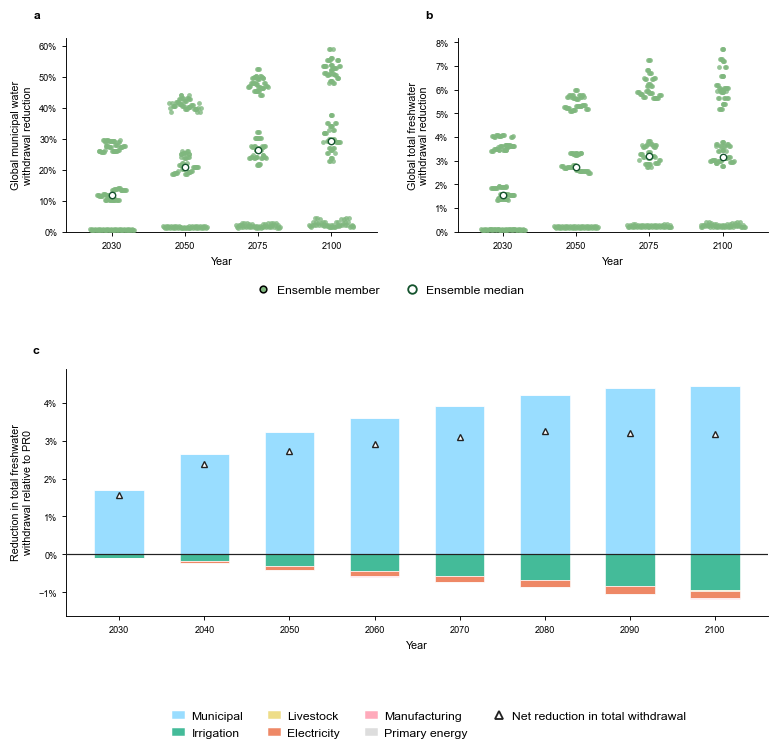

In [10]:
make_figure1("PR100", "Figure1_PR100")